In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
def h(pt1, pt2, startPoint, lam = 0, pref = 1):
    r1 = pt1 - startPoint
    r2 = pt2 - startPoint
    r1 += 1.5
    r1 %= 1
    r1 -= 0.5
    r2 += 1.5
    r2 %= 1
    r2 -= 0.5

    d = (pt2 - pt1) + 1.5
    d %= 1
    d -= 0.5
    return (r1[0] + r2[0]) * d[1] / 2 + lam * np.sqrt(np.sum(d**2))

<Figure size 640x480 with 0 Axes>

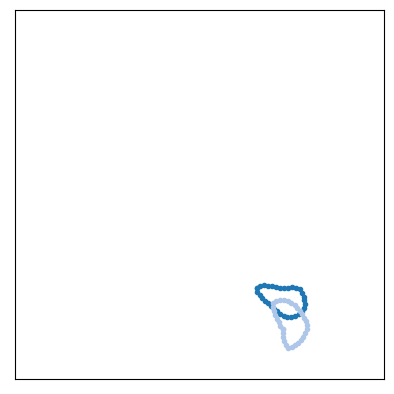

88 0.004290671860995663


<Figure size 640x480 with 0 Axes>

In [6]:
numPolygons = 2
lam = 0.01
pref = 1
n = 32
#nVals = [25, 66, 88, 170, 202, 235, 284, 286, 339, 405]
nVals = [88]
for i in nVals:
    m = pcp.model(size = n * numPolygons, seed = i)
    m.setModelEnum("normal")
    m.generateRandomPolygons(numPolygons = numPolygons, n = n, kappa = 4.0, phi = 0.015)
    # Works fine
    m.setMaxEdgeLength()
    # use default max edge length by finding it within the simulation
    # You can adjust this later.
    m.initializeNeighborCells()
    m.updateNeighborCells()
    olPY, _ = m.functional(h, lam = lam, pref = pref)
    if (olPY == 0):
        continue
    plt.clf()
    ax = m.draw(numbering = False)
#    if (np.abs(1-olPY / oa) > 5e-4):
    plt.show()
    plt.clf()
    print(i, olPY)